# Laboratorio 7 — Spark MLlib
## 08. Visualización y análisis de errores

Se analiza **dónde y en qué dirección se equivocan** los dos modelos finales sobre el primer trimestre de 2026.

- **Residuo = salario real − salario predicho.** Un residuo **positivo** indica **subestimación** (el modelo predijo menos de lo que la persona gana); uno **negativo**, **sobreestimación**.
- Los gráficos de dispersión usan **una misma muestra** de hasta 5,000 registros de prueba para los dos modelos, tomada con semilla fija. Solo sirve para dibujar.
- Las métricas por grupo, por tramo de salario y por decil de predicción se calculan en Spark con **todos** los registros de prueba.
- Los resultados describen los registros analizados (no ponderados) y no son causales.

In [1]:
import sys
from pathlib import Path

RAIZ = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from pyspark.sql import functions as F

from src import config, evaluacion, exploracion, modelado

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

for d in (config.FIGURES, config.TABLES):
    d.mkdir(parents=True, exist_ok=True)

spark = config.crear_spark("lab7_08_analisis_errores")
spark.sparkContext.setLogLevel("ERROR")

Para que este notebook corra solo, sin depender de variables ni de modelos guardados por otro, se repiten los pasos de la actividad 7: se leen las configuraciones elegidas en validación, se reentrenan con los cuatro trimestres de 2025 y se predice 2026. La regresión es determinista y el bosque usa semilla fija, así que las predicciones son las mismas de la actividad 7.

In [2]:
desarrollo = modelado.leer_preparado(spark, "personas_2025").persist()
prueba = modelado.cargar_prueba(spark).persist()
nombre_lineal, reg_param, elastic_net = evaluacion.parametros_lineal()
nombre_bosque, num_trees, max_depth = evaluacion.parametros_random_forest()
modelos = evaluacion.entrenar_finales(desarrollo, (reg_param, elastic_net), (num_trees, max_depth))
media_ref = modelado.referencia(desarrollo, "media")
pred = evaluacion.predecir(modelos, prueba, media_ref).persist()
tabla_prueba = evaluacion.metricas_prueba(pred)
tabla_prueba

,modelo,mae,rmse,r2,n
0,referencia,"1,718.086","2,871.421",-0.003,"13,258.000"
1,regresión lineal,"1,240.711","2,163.752",0.431,"13,258.000"
2,random forest,"1,063.684","1,891.371",0.565,"13,258.000"


In [3]:
COLOR = {"regresion_lineal": "#e90", "random_forest": "#357"}
q = lambda v: f"-Q{abs(v):,.0f}" if v < 0 else f"Q{v:,.0f}"

## 1. Distribución y percentiles del salario

Antes de mirar los errores conviene recordar cómo es el objetivo. Se comparan la media, la desviación estándar y los percentiles del salario real de entrenamiento (2025) y de prueba (2026 I), calculados con todos los registros.

In [4]:
percentiles = evaluacion.percentiles_salario({"2025 (entrenamiento)": desarrollo, "2026 I (prueba)": prueba})
forma = {nombre: exploracion.asimetria(df, modelado.OBJETIVO)
         for nombre, df in {"2025 (entrenamiento)": desarrollo, "2026 I (prueba)": prueba}.items()}
percentiles.loc["asimetria"] = [forma[c]["asimetria"] for c in percentiles.columns]
percentiles

,2025 (entrenamiento),2026 I (prueba)
estadistico,,
n,"53,025.000","13,258.000"
media,"3,421.684","3,565.796"
desv_estandar,"2,902.109","2,867.910"
maximo,"99,000.000","60,000.000"
p5,600.000,750.000
p10,900.000,"1,000.000"
p25,"1,800.000","2,000.000"
p50,"3,000.000","3,200.000"
p75,"4,000.000","4,066.000"


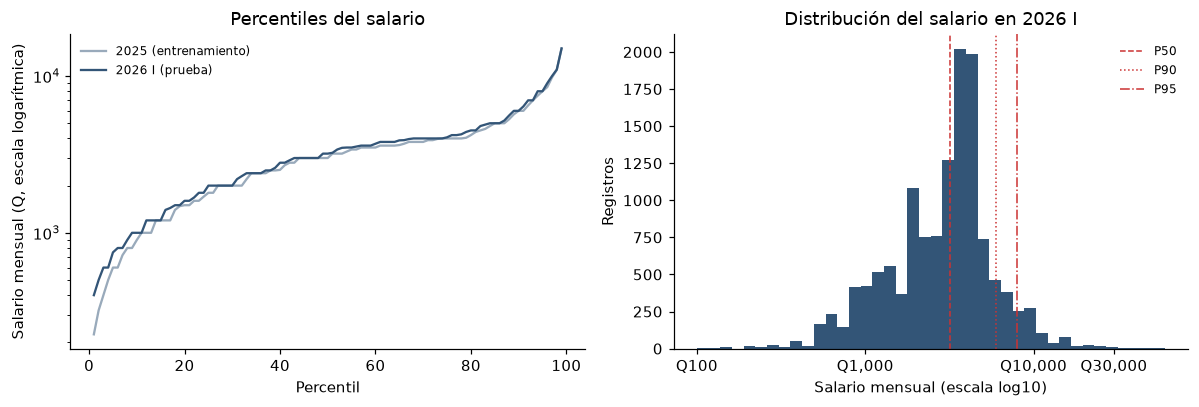

In [5]:
puntos = [i / 100 for i in range(1, 100)]
curvas = {nombre: df.approxQuantile(modelado.OBJETIVO, puntos, 0.001)
          for nombre, df in {"2025 (entrenamiento)": desarrollo, "2026 I (prueba)": prueba}.items()}
hist = exploracion.histograma(prueba, modelado.OBJETIVO, bins=40, log10=True)

fig, ejes = plt.subplots(1, 2, figsize=(11, 3.8))
for (nombre, valores), color in zip(curvas.items(), ["#9ab", "#357"]):
    ejes[0].plot([100 * p for p in puntos], valores, label=nombre, color=color)
ejes[0].set_yscale("log")
ejes[0].set_xlabel("Percentil")
ejes[0].set_ylabel("Salario mensual (Q, escala logarítmica)")
ejes[0].set_title("Percentiles del salario")
ejes[0].legend(frameon=False, fontsize=8)
ejes[1].bar(hist["desde"], hist["registros"], width=hist["hasta"] - hist["desde"], align="edge", color="#357")
for p, estilo in [(0.5, "--"), (0.9, ":"), (0.95, "-.")]:
    valor = np.log10(percentiles.loc[f"p{round(100 * p)}", "2026 I (prueba)"])
    ejes[1].axvline(valor, color="#c33", ls=estilo, lw=1, label=f"P{round(100 * p)}")
ticks = [2, 3, 4, np.log10(30000)]
ejes[1].set_xticks(ticks, [f"Q{10 ** t:,.0f}" for t in ticks])
ejes[1].set_xlabel("Salario mensual (escala log10)")
ejes[1].set_ylabel("Registros")
ejes[1].set_title("Distribución del salario en 2026 I")
ejes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(config.FIGURES / "08_percentiles_salario.png", bbox_inches="tight")
plt.show()

In [6]:
p25, p26 = percentiles["2025 (entrenamiento)"], percentiles["2026 I (prueba)"]
display(Markdown(f"""
**Lectura.**

- El salario es **muy asimétrico a la derecha** en los dos años (asimetría {p25['asimetria']:.1f} en 2025 y {p26['asimetria']:.1f} en 2026): la media (Q{p26['media']:,.0f} en 2026) supera a la mediana (Q{p26['p50']:,.0f}), y la desviación estándar (Q{p26['desv_estandar']:,.0f}) equivale a {100 * p26['desv_estandar'] / p26['media']:.0f} % de la media.
- La mitad central de 2026 está entre Q{p26['p25']:,.0f} y Q{p26['p75']:,.0f}, pero el P95 es Q{p26['p95']:,.0f}, el P99 Q{p26['p99']:,.0f} y el máximo Q{p26['maximo']:,.0f}. La curva de percentiles se empina en el último 10 %: **pocos registros con salarios muy altos** concentran buena parte de la varianza del objetivo.
- 2026 es algo más alto que 2025 en la parte baja y media (P25 Q{p26['p25']:,.0f} frente a Q{p25['p25']:,.0f}; mediana Q{p26['p50']:,.0f} frente a Q{p25['p50']:,.0f}), mientras que P90, P95 y P99 coinciden. Los modelos se entrenan con el nivel de 2025, así que es de esperar un leve sesgo de subestimación general en 2026.
- Muchos salarios se declaran en cifras redondas (Q2,000, Q3,000, Q4,000...), por lo que varios percentiles caen exactamente en esos valores.
"""))


**Lectura.**

- El salario es **muy asimétrico a la derecha** en los dos años (asimetría 6.0 en 2025 y 4.4 en 2026): la media (Q3,566 en 2026) supera a la mediana (Q3,200), y la desviación estándar (Q2,868) equivale a 80 % de la media.
- La mitad central de 2026 está entre Q2,000 y Q4,066, pero el P95 es Q8,000, el P99 Q15,000 y el máximo Q60,000. La curva de percentiles se empina en el último 10 %: **pocos registros con salarios muy altos** concentran buena parte de la varianza del objetivo.
- 2026 es algo más alto que 2025 en la parte baja y media (P25 Q2,000 frente a Q1,800; mediana Q3,200 frente a Q3,000), mientras que P90, P95 y P99 coinciden. Los modelos se entrenan con el nivel de 2025, así que es de esperar un leve sesgo de subestimación general en 2026.
- Muchos salarios se declaran en cifras redondas (Q2,000, Q3,000, Q4,000...), por lo que varios percentiles caen exactamente en esos valores.


## 2. Salario real frente a salario predicho

Cada punto es un registro de la **misma muestra** para los dos modelos. Sobre la línea y = x la predicción es perfecta; los puntos **por encima** de la línea están **subestimados** (real mayor que predicho) y los que están **por debajo**, sobreestimados.

Arriba se usan ejes lineales, recortados al percentil 99.5 de la muestra para que la nube sea visible (se indica cuántos puntos quedan fuera). Abajo, los mismos puntos en **escala logarítmica** en ambos ejes, donde se ven completos los salarios bajos y los extremos. Las predicciones negativas no se pueden dibujar en escala logarítmica y se indican aparte.

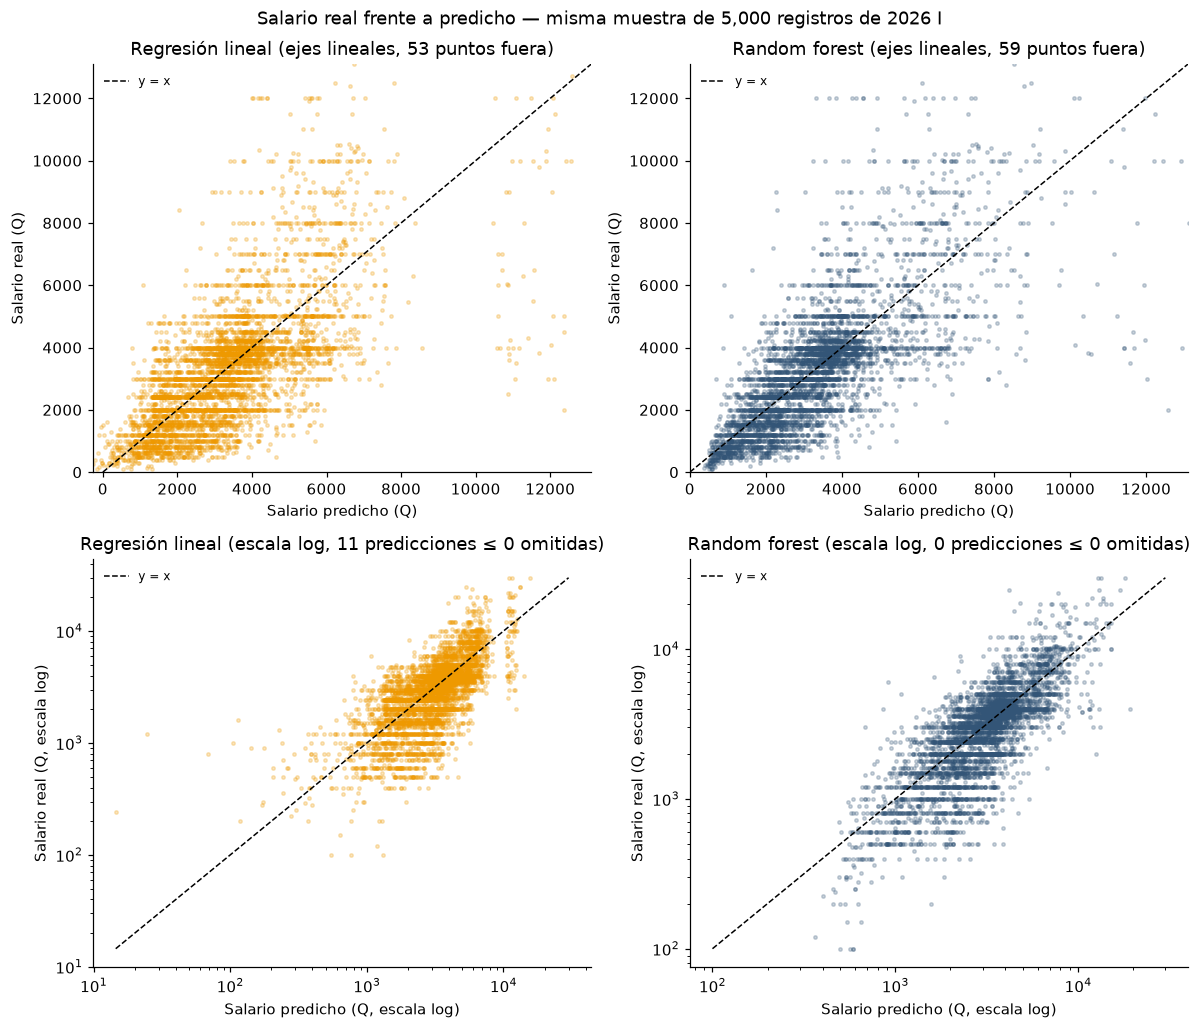

In [7]:
muestra = evaluacion.muestra_comun(pred)
limite = float(np.quantile(muestra[[modelado.OBJETIVO] + [evaluacion.PREDICCIONES[m] for m in evaluacion.MODELOS]].values, 0.995))

fig, ejes = plt.subplots(2, 2, figsize=(11, 9.5))
for j, m in enumerate(evaluacion.MODELOS):
    x, y = muestra[evaluacion.PREDICCIONES[m]], muestra[modelado.OBJETIVO]
    fuera = int(((x > limite) | (y > limite)).sum())
    eje = ejes[0, j]
    eje.scatter(x, y, s=5, alpha=0.25, color=COLOR[m])
    eje.plot([0, limite], [0, limite], color="k", ls="--", lw=1, label="y = x")
    eje.set_xlim(min(0, x.min()), limite)
    eje.set_ylim(0, limite)
    eje.set_title(f"{evaluacion.NOMBRES[m].capitalize()} (ejes lineales, {fuera} puntos fuera)")
    eje.set_xlabel("Salario predicho (Q)")
    eje.set_ylabel("Salario real (Q)")
    eje.legend(frameon=False, fontsize=8, loc="upper left")

    positivos = x > 0
    eje = ejes[1, j]
    eje.scatter(x[positivos], y[positivos], s=5, alpha=0.25, color=COLOR[m])
    extremo = [min(x[positivos].min(), y.min()), max(x.max(), y.max())]
    eje.plot(extremo, extremo, color="k", ls="--", lw=1, label="y = x")
    eje.set_xscale("log")
    eje.set_yscale("log")
    eje.set_title(f"{evaluacion.NOMBRES[m].capitalize()} (escala log, {int((~positivos).sum())} predicciones ≤ 0 omitidas)")
    eje.set_xlabel("Salario predicho (Q, escala log)")
    eje.set_ylabel("Salario real (Q, escala log)")
    eje.legend(frameon=False, fontsize=8, loc="upper left")
fig.suptitle(f"Salario real frente a predicho — misma muestra de {len(muestra):,} registros de 2026 I")
fig.tight_layout()
fig.savefig(config.FIGURES / "08_real_vs_predicho.png", bbox_inches="tight")
plt.show()

In [8]:
rango = evaluacion.rango_predicciones(pred)
display(rango)
r = rango
posgrado = pred.filter(F.col("nivel_educativo").isin("6", "7")).agg(
    F.count("*").alias("n"), F.avg(evaluacion.PREDICCIONES["regresion_lineal"]).alias("pred_rl"),
    F.avg(evaluacion.PREDICCIONES["random_forest"]).alias("pred_rf"),
    F.expr("percentile(salario_mensual, 0.1)").alias("p10"),
    F.expr("percentile(salario_mensual, 0.9)").alias("p90")).first()
display(Markdown(f"""
**Lectura.**

- En los dos modelos la nube es **más plana que la línea y = x**: las predicciones se mueven en un rango mucho más estrecho que los salarios reales. Con los registros completos de prueba, el P99 de lo predicho es Q{r.loc['regresión lineal', 'p99']:,.0f} (regresión) y Q{r.loc['random forest', 'p99']:,.0f} (bosque), frente a Q{r.loc['salario real', 'p99']:,.0f} del salario real.
- A la derecha del gráfico, los salarios reales altos quedan casi siempre **por encima** de la línea (subestimados); abajo a la izquierda, muchos salarios bajos quedan **por debajo** (sobreestimados).
- La **regresión lineal** predice **{int(r.loc['regresión lineal', 'negativos'])} salarios negativos** en 2026 (mínimo {q(r.loc['regresión lineal', 'minimo'])}), algo imposible: suma efectos fijos y, para perfiles con pocas horas, poca edad y categorías de salario bajo, la suma cae por debajo de cero.
- El **Random Forest** nunca predice fuera del rango observado en 2025 (mínimo Q{r.loc['random forest', 'minimo']:,.0f}, sin negativos) y su nube se acerca más a la diagonal en los salarios medios y altos, aunque también los recorta.
- A la derecha, sobre todo en la regresión, se separa un **grupo de predicciones cercanas a Q11,000**: son las {posgrado['n']} personas con maestría o doctorado, a quienes el nivel educativo les suma varios miles de quetzales por igual (predicción media Q{posgrado['pred_rl']:,.0f} en la regresión y Q{posgrado['pred_rf']:,.0f} en el bosque). Sus salarios reales, en cambio, van de Q{posgrado['p10']:,.0f} (P10) a Q{posgrado['p90']:,.0f} (P90), por lo que en ese grupo hay a la vez grandes sobreestimaciones y grandes subestimaciones.
"""))

,minimo,p1,p99,maximo,negativos
salario real,100.000,400.000,"15,000.000","60,000.000",0.000
regresión lineal,-495.634,398.516,"10,947.586","15,663.124",29.000
random forest,364.858,630.833,"10,596.267","36,143.449",0.000



**Lectura.**

- En los dos modelos la nube es **más plana que la línea y = x**: las predicciones se mueven en un rango mucho más estrecho que los salarios reales. Con los registros completos de prueba, el P99 de lo predicho es Q10,948 (regresión) y Q10,596 (bosque), frente a Q15,000 del salario real.
- A la derecha del gráfico, los salarios reales altos quedan casi siempre **por encima** de la línea (subestimados); abajo a la izquierda, muchos salarios bajos quedan **por debajo** (sobreestimados).
- La **regresión lineal** predice **29 salarios negativos** en 2026 (mínimo -Q496), algo imposible: suma efectos fijos y, para perfiles con pocas horas, poca edad y categorías de salario bajo, la suma cae por debajo de cero.
- El **Random Forest** nunca predice fuera del rango observado en 2025 (mínimo Q365, sin negativos) y su nube se acerca más a la diagonal en los salarios medios y altos, aunque también los recorta.
- A la derecha, sobre todo en la regresión, se separa un **grupo de predicciones cercanas a Q11,000**: son las 195 personas con maestría o doctorado, a quienes el nivel educativo les suma varios miles de quetzales por igual (predicción media Q11,595 en la regresión y Q11,853 en el bosque). Sus salarios reales, en cambio, van de Q4,000 (P10) a Q21,600 (P90), por lo que en ese grupo hay a la vez grandes sobreestimaciones y grandes subestimaciones.


## 3. Residuos frente al salario predicho

Con la misma muestra se dibuja el residuo (real − predicho) contra lo predicho, con una línea horizontal en cero. Encima se traza el **error medio por decil de lo predicho**, calculado con **todos** los registros de prueba: si un modelo no tuviera sesgo, esa línea quedaría pegada al cero en todo el rango.

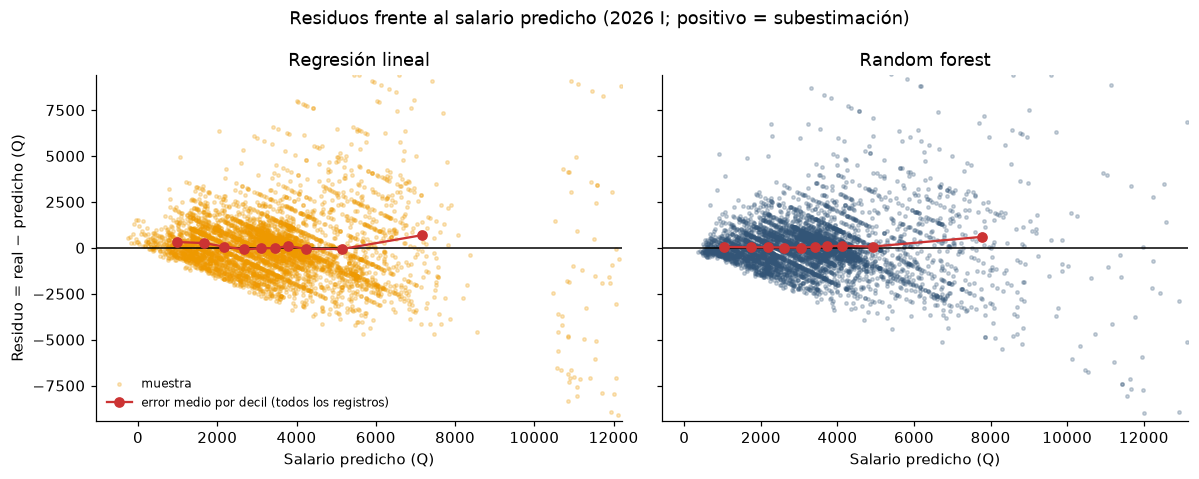

regresión lineal                                                           random forest                                                          
                     n prediccion_media salario_real_medio       mae error_medio             n prediccion_media salario_real_medio       mae error_medio
decil                                                                                                                                                   
0.000             1329          986.661          1,304.468   595.726     317.807          1329        1,026.392          1,077.609   400.011      51.216
1.000             1325        1,657.176          1,918.448   805.502     261.273          1325        1,735.980          1,769.718   639.554      33.738
2.000             1311        2,171.260          2,240.897   900.979      69.637          1311        2,192.844          2,225.405   794.544      32.561
3.000             1337        2,682.158          2,597.536   964.369     -84.622          1337        2,595.951          2,612.066   865.959      16.115
4.000             1321        3,115.194          3,092.164   981.985     -23.031          1321        3,043.148          3,055.289   895.881      12.141
5.000             1318        3,460.922          3,449.971   955.533     -10.950          1319        3,415.642          3,465.381   838.430      49.739
6.000             1331        3,792.855          3,889.182   916.400      96.327          1330        3,725.696          3,813.550   789.900      87.854
7.000             1325        4,229.630          4,174.025 1,158.707     -55.605          1325        4,122.344          4,234.925   938.583     112.580
8.000             1323        5,150.901          5,086.980 1,858.678     -63.921          1323        4,918.012          4,986.137 1,426.686      68.124
9.000             1338        7,170.104          7,862.516 3,250.482     692.413          1338        7,772.873          8,371.924 3,029.017     599.051

In [9]:
deciles = {m: evaluacion.error_por_decil_prediccion(pred, m) for m in evaluacion.MODELOS}
limite_res = float(np.quantile(np.abs(muestra[[evaluacion.RESIDUOS[m] for m in evaluacion.MODELOS]].values), 0.995))

fig, ejes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
for eje, m in zip(ejes, evaluacion.MODELOS):
    x, y = muestra[evaluacion.PREDICCIONES[m]], muestra[evaluacion.RESIDUOS[m]]
    eje.scatter(x, y, s=5, alpha=0.25, color=COLOR[m], label="muestra")
    eje.axhline(0, color="k", lw=1)
    eje.plot(deciles[m]["prediccion_media"], deciles[m]["error_medio"], color="#c33", marker="o", lw=1.5,
             label="error medio por decil (todos los registros)")
    eje.set_xlim(right=float(np.quantile(x, 0.995)) * 1.05)
    eje.set_ylim(-limite_res, limite_res)
    eje.set_title(evaluacion.NOMBRES[m].capitalize())
    eje.set_xlabel("Salario predicho (Q)")
ejes[0].set_ylabel("Residuo = real − predicho (Q)")
ejes[0].legend(frameon=False, fontsize=8, loc="lower left")
fig.suptitle("Residuos frente al salario predicho (2026 I; positivo = subestimación)")
fig.tight_layout()
fig.savefig(config.FIGURES / "08_residuos_vs_predicho.png", bbox_inches="tight")
plt.show()

pd.concat({evaluacion.NOMBRES[m]: d.set_index("decil") for m, d in deciles.items()}, axis=1)

In [10]:
dl, dr = deciles["regresion_lineal"], deciles["random_forest"]
display(Markdown(f"""
**Lectura.**

- **La dispersión crece con lo predicho (heterocedasticidad).** En el decil más bajo de predicción el MAE es {q(dl['mae'].iloc[0])} en la regresión y {q(dr['mae'].iloc[0])} en el bosque; en el más alto sube a {q(dl['mae'].iloc[-1])} y {q(dr['mae'].iloc[-1])}. Un mismo modelo se equivoca más, en quetzales, con quienes predice que ganan más.
- **La nube no es simétrica.** Hacia abajo el residuo está acotado (el salario real no puede ser menor que cero, así que el residuo nunca baja de −predicho; eso forma el borde diagonal inferior), mientras que hacia arriba hay residuos de decenas de miles de quetzales: son los salarios altos que ningún modelo anticipa.
- Las **franjas diagonales** se deben a los salarios redondos: todas las personas que ganan, por ejemplo, Q3,000 forman una recta de pendiente −1 (a mayor predicción, menor residuo), y hay una recta por cada monto frecuente.
- **Error medio por decil.** En los deciles 3.º a 9.º el error medio queda cerca de cero: entre {q(dl['error_medio'].iloc[2:-1].min())} y {q(dl['error_medio'].iloc[2:-1].max())} en la regresión y entre {q(dr['error_medio'].iloc[2:-1].min())} y {q(dr['error_medio'].iloc[2:-1].max())} en el bosque. Para esos niveles de predicción, los errores se compensan en promedio.
- En el **decil más alto** los dos modelos subestiman en promedio ({q(dl['error_medio'].iloc[-1])} la regresión y {q(dr['error_medio'].iloc[-1])} el bosque): cuando predicen salarios altos, las personas ganan todavía más, porque la cola derecha del salario sigue más allá de lo que los modelos alcanzan a predecir. En los **dos deciles más bajos**, la regresión también subestima ({q(dl['error_medio'].iloc[0])} y {q(dl['error_medio'].iloc[1])}): sus predicciones más bajas, incluidas las negativas, caen por debajo de lo que esas personas ganan. El bosque, en cambio, queda cerca de cero ({q(dr['error_medio'].iloc[0])} y {q(dr['error_medio'].iloc[1])}).
"""))


**Lectura.**

- **La dispersión crece con lo predicho (heterocedasticidad).** En el decil más bajo de predicción el MAE es Q596 en la regresión y Q400 en el bosque; en el más alto sube a Q3,250 y Q3,029. Un mismo modelo se equivoca más, en quetzales, con quienes predice que ganan más.
- **La nube no es simétrica.** Hacia abajo el residuo está acotado (el salario real no puede ser menor que cero, así que el residuo nunca baja de −predicho; eso forma el borde diagonal inferior), mientras que hacia arriba hay residuos de decenas de miles de quetzales: son los salarios altos que ningún modelo anticipa.
- Las **franjas diagonales** se deben a los salarios redondos: todas las personas que ganan, por ejemplo, Q3,000 forman una recta de pendiente −1 (a mayor predicción, menor residuo), y hay una recta por cada monto frecuente.
- **Error medio por decil.** En los deciles 3.º a 9.º el error medio queda cerca de cero: entre -Q85 y Q96 en la regresión y entre Q12 y Q113 en el bosque. Para esos niveles de predicción, los errores se compensan en promedio.
- En el **decil más alto** los dos modelos subestiman en promedio (Q692 la regresión y Q599 el bosque): cuando predicen salarios altos, las personas ganan todavía más, porque la cola derecha del salario sigue más allá de lo que los modelos alcanzan a predecir. En los **dos deciles más bajos**, la regresión también subestima (Q318 y Q261): sus predicciones más bajas, incluidas las negativas, caen por debajo de lo que esas personas ganan. El bosque, en cambio, queda cerca de cero (Q51 y Q34).


## 4. Error por nivel educativo y por dominio

MAE y error medio (promedio del residuo) de cada modelo por categoría, con el número de observaciones de cada grupo. Se calculan con **todos** los registros de prueba. Un error medio positivo indica que el grupo, en promedio, queda subestimado.

In [11]:
columnas_tabla = ["categoria", "n", "salario_real_medio",
                  "mae_regresion_lineal", "error_medio_regresion_lineal",
                  "mae_random_forest", "error_medio_random_forest"]
error_educacion = evaluacion.error_por_grupo(pred, "nivel_educativo")
error_dominio = evaluacion.error_por_grupo(pred, "dominio")
display(Markdown("**Por nivel educativo** (todos los registros de 2026 I)"))
display(error_educacion[columnas_tabla])
display(Markdown("**Por dominio** (todos los registros de 2026 I)"))
display(error_dominio[columnas_tabla])

**Por nivel educativo** (todos los registros de 2026 I)

,categoria,n,salario_real_medio,mae_regresion_lineal,error_medio_regresion_lineal,mae_random_forest,error_medio_random_forest
0,ninguno,1016,"1,884.136",823.513,109.340,605.351,62.742
1,preprimaria,80,"2,374.562",735.206,88.762,534.731,57.144
2,primaria,3957,"2,422.747",870.036,54.555,736.557,57.291
3,básico,2164,"2,905.455",894.451,127.770,776.477,123.822
4,diversificado,4117,"3,924.239","1,109.314",103.977,986.313,95.733
5,superior,1729,"6,264.360","2,566.370",295.514,"2,225.667",266.566
6,maestría,183,"11,290.639","5,552.879",-131.504,"4,522.767",-324.689
7,doctorado,12,"20,291.667","12,919.309","6,062.704","9,430.493","4,812.189"


**Por dominio** (todos los registros de 2026 I)

,categoria,n,salario_real_medio,mae_regresion_lineal,error_medio_regresion_lineal,mae_random_forest,error_medio_random_forest
0,urbano metropolitano,5632,"4,352.308","1,446.093",136.036,"1,282.448",145.355
1,resto urbano,4846,"3,281.639","1,189.647",134.283,997.812,93.178
2,rural nacional,2780,"2,467.733",913.639,65.243,735.319,52.569


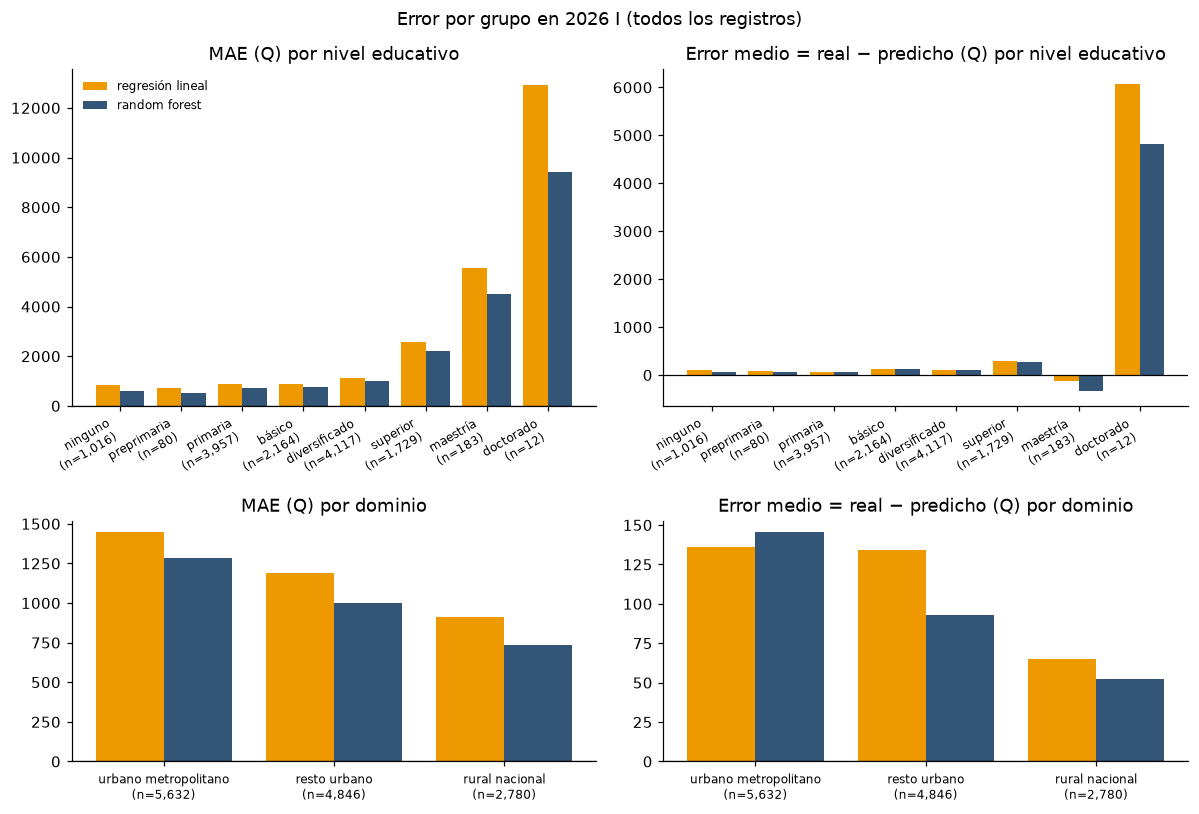

In [12]:
fig, ejes = plt.subplots(2, 2, figsize=(11, 7.5), gridspec_kw={"height_ratios": [1.4, 1]})
for fila, tabla in enumerate([error_educacion, error_dominio]):
    pos = np.arange(len(tabla))
    etiquetas = [f"{c}\n(n={n:,})" for c, n in zip(tabla["categoria"], tabla["n"])]
    for col, (metrica, titulo) in enumerate([("mae", "MAE (Q)"), ("error_medio", "Error medio = real − predicho (Q)")]):
        eje = ejes[fila, col]
        for desplazamiento, m in zip([-0.2, 0.2], evaluacion.MODELOS):
            eje.bar(pos + desplazamiento, tabla[f"{metrica}_{m}"], width=0.4, color=COLOR[m], label=evaluacion.NOMBRES[m])
        eje.axhline(0, color="k", lw=0.8)
        eje.set_xticks(pos, etiquetas, rotation=30 if fila == 0 else 0, ha="right" if fila == 0 else "center", fontsize=8)
        eje.set_title(f"{titulo} por {'nivel educativo' if fila == 0 else 'dominio'}")
ejes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("Error por grupo en 2026 I (todos los registros)")
fig.tight_layout()
fig.savefig(config.FIGURES / "08_error_por_grupo.png", bbox_inches="tight")
plt.show()

In [13]:
e = error_educacion.set_index("categoria")
d = error_dominio.set_index("categoria")
relativo = lambda t, m: 100 * t[f"mae_{m}"] / t["salario_real_medio"]
e_rel = relativo(e, "random_forest")
grandes = e[e["n"] >= 100]
display(Markdown(f"""
**Lectura.**

- **Nivel educativo.** El MAE crece con la educación porque también crecen el salario y su dispersión: en el bosque va de {q(e.loc['ninguno', 'mae_random_forest'])} (ninguno, n = {e.loc['ninguno', 'n']:,}) a {q(e.loc['superior', 'mae_random_forest'])} (superior, n = {e.loc['superior', 'n']:,}) y {q(e.loc['maestría', 'mae_random_forest'])} (maestría, n = {e.loc['maestría', 'n']:,}). En términos relativos al salario medio del grupo, el error va de {e_rel.min():.0f} % a {e_rel.max():.0f} %: incluso en los grupos de salario bajo el error típico es una fracción grande del salario.
- El error medio es **positivo en casi todos los niveles** (subestimación promedio de unos Q50 a Q300), coherente con que 2026 gana algo más que 2025. La excepción es maestría (error medio {q(e.loc['maestría', 'error_medio_random_forest'])} en el bosque), y **doctorado** tiene solo {e.loc['doctorado', 'n']} registros con un error medio de {q(e.loc['doctorado', 'error_medio_random_forest'])}: con tan pocos casos, esa cifra es inestable y no permite conclusiones.
- El Random Forest tiene menor MAE que la regresión en **{int((e['mae_random_forest'] < e['mae_regresion_lineal']).sum())} de {len(e)}** niveles educativos; entre los niveles con al menos 100 registros, la mejora va de {q((grandes['mae_regresion_lineal'] - grandes['mae_random_forest']).min())} a {q((grandes['mae_regresion_lineal'] - grandes['mae_random_forest']).max())}.
- **Dominio.** El error es mayor en el urbano metropolitano (MAE {q(d.loc['urbano metropolitano', 'mae_random_forest'])} en el bosque, salario medio {q(d.loc['urbano metropolitano', 'salario_real_medio'])}) que en el resto urbano ({q(d.loc['resto urbano', 'mae_random_forest'])}) y en el rural nacional ({q(d.loc['rural nacional', 'mae_random_forest'])}). Los tres dominios quedan levemente subestimados en promedio, y el bosque mejora a la regresión en los tres.
"""))


**Lectura.**

- **Nivel educativo.** El MAE crece con la educación porque también crecen el salario y su dispersión: en el bosque va de Q605 (ninguno, n = 1,016) a Q2,226 (superior, n = 1,729) y Q4,523 (maestría, n = 183). En términos relativos al salario medio del grupo, el error va de 23 % a 46 %: incluso en los grupos de salario bajo el error típico es una fracción grande del salario.
- El error medio es **positivo en casi todos los niveles** (subestimación promedio de unos Q50 a Q300), coherente con que 2026 gana algo más que 2025. La excepción es maestría (error medio -Q325 en el bosque), y **doctorado** tiene solo 12 registros con un error medio de Q4,812: con tan pocos casos, esa cifra es inestable y no permite conclusiones.
- El Random Forest tiene menor MAE que la regresión en **8 de 8** niveles educativos; entre los niveles con al menos 100 registros, la mejora va de Q118 a Q1,030.
- **Dominio.** El error es mayor en el urbano metropolitano (MAE Q1,282 en el bosque, salario medio Q4,352) que en el resto urbano (Q998) y en el rural nacional (Q735). Los tres dominios quedan levemente subestimados en promedio, y el bosque mejora a la regresión en los tres.


## 5. Error por percentil del salario real: ¿se subestiman los salarios altos?

Se agrupan los registros de prueba por su **salario real**, con cortes en los percentiles 25, 50, 75, 90 y 95 de 2026, para separar la cola alta. Para cada modelo se calcula, con todos los registros, la predicción media, el MAE y el error medio de cada tramo. Los salarios redondos hacen que algunos tramos tengan más registros que otros, porque todos los empates quedan del mismo lado del corte.

In [14]:
cortes = evaluacion.cortes_tramos(pred)
tramos = evaluacion.error_por_tramo(pred, cortes)
tramos.pivot(index=["tramo", "rango", "n", "salario_real_medio"], columns="modelo",
             values=["prediccion_media", "mae", "error_medio"])

prediccion_media                            mae                    error_medio                 
modelo                                           random forest regresión lineal random forest regresión lineal random forest regresión lineal
tramo rango           n    salario_real_medio                                                                                                
0     <= Q2,000       4032 1,297.680                 1,997.381        2,126.411       800.336          998.388      -699.701         -828.730
1     Q2,000 - Q3,200 2715 2,738.187                 2,871.401        2,899.272       672.589          851.676      -133.214         -161.085
2     Q3,200 - Q4,066 3188 3,769.052                 3,828.532        3,848.696       738.802          830.818       -59.480          -79.644
3     Q4,066 - Q6,000 2072 4,888.552                 4,441.303        4,402.371     1,151.008        1,177.646       447.249          486.181
4     Q6,000 - Q8,000 608  7,224.814                 5,814.550        5,590.541     1,895.485        2,076.143     1,410.264        1,634.273
5     > Q8,000        643  12,552.706                7,879.812        6,907.367     4,909.254        5,848.389     4,672.894        5,645.339

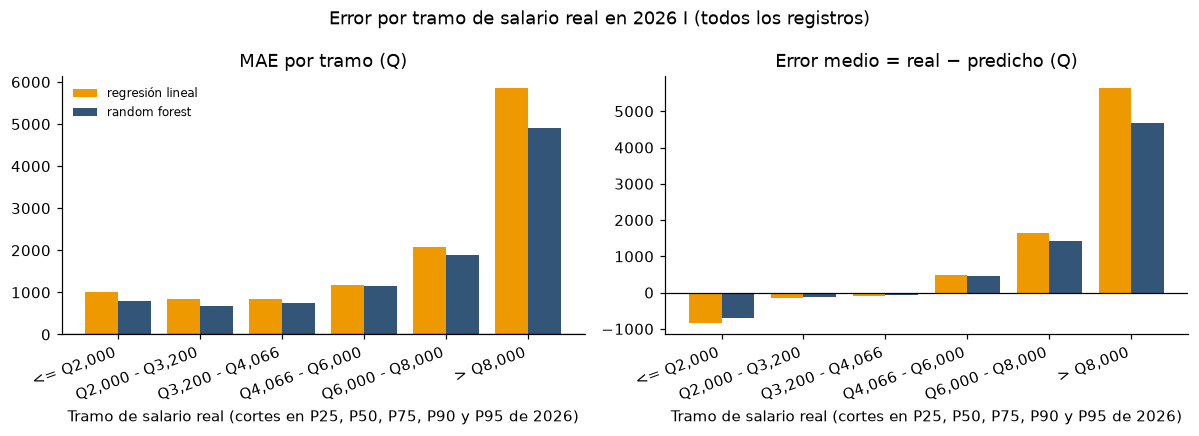

In [15]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 4))
rangos = tramos.loc[tramos["modelo"] == "random forest", "rango"].tolist()
pos = np.arange(len(rangos))
for eje, metrica, titulo in zip(ejes, ["mae", "error_medio"], ["MAE por tramo (Q)", "Error medio = real − predicho (Q)"]):
    for desplazamiento, m in zip([-0.2, 0.2], evaluacion.MODELOS):
        valores = tramos.loc[tramos["modelo"] == evaluacion.NOMBRES[m], metrica]
        eje.bar(pos + desplazamiento, valores, width=0.4, color=COLOR[m], label=evaluacion.NOMBRES[m])
    eje.axhline(0, color="k", lw=0.8)
    eje.set_xticks(pos, rangos, rotation=20, ha="right")
    eje.set_xlabel("Tramo de salario real (cortes en P25, P50, P75, P90 y P95 de 2026)")
    eje.set_title(titulo)
ejes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Error por tramo de salario real en 2026 I (todos los registros)")
fig.tight_layout()
fig.savefig(config.FIGURES / "08_error_por_tramo.png", bbox_inches="tight")
plt.show()

In [16]:
resumen = evaluacion.resumen_errores(pred, umbral_alto=cortes[3], umbral_cola=cortes[4])
resumen

,modelo,mediana_error_absoluto,pct_error_hasta_20pct,pct_subestimados,pct_subestimados_salario_alto,pct_error_cuadratico_cola
0,regresión lineal,800.783,37.819,48.944,92.326,61.737
1,random forest,638.742,45.671,48.122,88.649,58.629


In [17]:
t = tramos.set_index(["modelo", "tramo"])
ultimo = len(cortes)
s = resumen.set_index("modelo")
rl, rf = s.loc["regresión lineal"], s.loc["random forest"]
alto_rl, alto_rf = t.loc[("regresión lineal", ultimo)], t.loc[("random forest", ultimo)]
bajo_rl, bajo_rf = t.loc[("regresión lineal", 0)], t.loc[("random forest", 0)]
display(Markdown(f"""
**Lectura.**

- **¿Los errores son grandes?** Sí, frente al salario típico. La mitad de las predicciones del bosque se equivoca en más de {q(rf['mediana_error_absoluto'])} (regresión: {q(rl['mediana_error_absoluto'])}), y solo {rf['pct_error_hasta_20pct']:.0f} % de los registros tiene un error de hasta 20 % de su salario real ({rl['pct_error_hasta_20pct']:.0f} % en la regresión).
- **Salarios bajos sobreestimados.** En el tramo más bajo ({bajo_rf['rango']}, salario real medio {q(bajo_rf['salario_real_medio'])}) el error medio es {q(bajo_rl['error_medio'])} en la regresión y {q(bajo_rf['error_medio'])} en el bosque.
- **Salarios altos subestimados.** Por encima del P95 ({alto_rf['rango']}, salario real medio {q(alto_rf['salario_real_medio'])}), la predicción media es {q(alto_rl['prediccion_media'])} en la regresión y {q(alto_rf['prediccion_media'])} en el bosque: un error medio de {q(alto_rl['error_medio'])} y {q(alto_rf['error_medio'])}. Por encima del P90 están subestimados el **{rl['pct_subestimados_salario_alto']:.0f} %** de los registros en la regresión y el **{rf['pct_subestimados_salario_alto']:.0f} %** en el bosque, frente a {rl['pct_subestimados']:.0f} % y {rf['pct_subestimados']:.0f} % en toda la prueba. **Hay una tendencia clara a subestimar los salarios altos.**
- **La cola manda en el RMSE.** El 5 % de registros con salario real mayor que el P95 aporta el **{rl['pct_error_cuadratico_cola']:.0f} %** de la suma de errores cuadráticos de la regresión y el **{rf['pct_error_cuadratico_cola']:.0f} %** de la del bosque. Por eso el RMSE es mucho mayor que el MAE, y por eso cualquier mejora en la cola se nota mucho en el RMSE.
- Es el patrón de **regresión hacia la media**: con predictores que explican algo más de la mitad de la variación, las predicciones se concentran cerca del centro. Los salarios muy altos dependen de factores que no están entre los seis predictores (ocupación concreta, rama de actividad, tamaño de la empresa, cargo); el modelo solo ve, por ejemplo, que la persona tiene educación superior y trabaja en el gobierno, y le asigna el salario típico de ese perfil. El bosque reduce el error en los extremos, pero no lo elimina.
"""))


**Lectura.**

- **¿Los errores son grandes?** Sí, frente al salario típico. La mitad de las predicciones del bosque se equivoca en más de Q639 (regresión: Q801), y solo 46 % de los registros tiene un error de hasta 20 % de su salario real (38 % en la regresión).
- **Salarios bajos sobreestimados.** En el tramo más bajo (<= Q2,000, salario real medio Q1,298) el error medio es -Q829 en la regresión y -Q700 en el bosque.
- **Salarios altos subestimados.** Por encima del P95 (> Q8,000, salario real medio Q12,553), la predicción media es Q6,907 en la regresión y Q7,880 en el bosque: un error medio de Q5,645 y Q4,673. Por encima del P90 están subestimados el **92 %** de los registros en la regresión y el **89 %** en el bosque, frente a 49 % y 48 % en toda la prueba. **Hay una tendencia clara a subestimar los salarios altos.**
- **La cola manda en el RMSE.** El 5 % de registros con salario real mayor que el P95 aporta el **62 %** de la suma de errores cuadráticos de la regresión y el **59 %** de la del bosque. Por eso el RMSE es mucho mayor que el MAE, y por eso cualquier mejora en la cola se nota mucho en el RMSE.
- Es el patrón de **regresión hacia la media**: con predictores que explican algo más de la mitad de la variación, las predicciones se concentran cerca del centro. Los salarios muy altos dependen de factores que no están entre los seis predictores (ocupación concreta, rama de actividad, tamaño de la empresa, cargo); el modelo solo ve, por ejemplo, que la persona tiene educación superior y trabaja en el gobierno, y le asigna el salario típico de ese perfil. El bosque reduce el error en los extremos, pero no lo elimina.


## 6. Guardado de tablas

In [18]:
error_educacion.to_csv(config.TABLES / "08_error_por_nivel_educativo.csv", index=False)
error_dominio.to_csv(config.TABLES / "08_error_por_dominio.csv", index=False)
tramos.to_csv(config.TABLES / "08_error_por_tramo_prueba.csv", index=False)
resumen.to_csv(config.TABLES / "08_resumen_errores.csv", index=False)
percentiles.to_csv(config.TABLES / "08_percentiles_salario.csv")
rango.to_csv(config.TABLES / "08_rango_predicciones.csv")
pd.concat({m: d for m, d in deciles.items()}, names=["modelo", "fila"]).reset_index(level=0).to_csv(
    config.TABLES / "08_error_por_decil_prediccion.csv", index=False)
print("Tablas:", sorted(p.name for p in config.TABLES.glob("08_*.csv")))
print("Figuras:", sorted(p.name for p in config.FIGURES.glob("08_*.png")))

Tablas: ['08_error_por_decil_prediccion.csv', '08_error_por_dominio.csv', '08_error_por_nivel_educativo.csv', '08_error_por_tramo_prueba.csv', '08_percentiles_salario.csv', '08_rango_predicciones.csv', '08_resumen_errores.csv']
Figuras: ['08_error_por_grupo.png', '08_error_por_tramo.png', '08_percentiles_salario.png', '08_real_vs_predicho.png', '08_residuos_vs_predicho.png']


## 7. Discusión final

Se reúnen los hallazgos de las ocho actividades para responder las dos preguntas del laboratorio.

In [19]:
tp = tabla_prueba.set_index("modelo")
ref, lin, rf = tp.loc["referencia"], tp.loc["regresión lineal"], tp.loc["random forest"]
display(Markdown(f"""
**Datos y población.** De los {203_676:,} registros de los cuatro archivos de 2025 quedaron 53,025 asalariados con salario positivo registrado (26 %), y {pred.count():,} en el primer trimestre de 2026, con las mismas reglas. Todo lo excluido corresponde a personas fuera de la población objetivo (menores de 15 años, no ocupados o no asalariados): los filtros de salario, antigüedad y horas no excluyeron a ningún asalariado, y el salario no se imputó. El archivo IV de 2025 trae 302 columnas en lugar de 270, por eso se unió por nombre (`unionByName`) y no por posición. Como la ENEIC es longitudinal con rotación, una misma persona puede aparecer en varios trimestres. Esas repeticiones no son duplicados, y por eso los conjuntos de entrenamiento, validación y prueba se separaron por período y no al azar. Todo el análisis es **no ponderado**: describe los registros, no a la población guatemalteca. Para estimaciones poblacionales habría que usar `FACTOR` como peso.

**El objetivo.** El salario mensual es muy asimétrico: la media (Q3,422 en 2025) supera a la mediana (Q3,000), y el P95 (Q8,000) y el máximo (Q99,000) están muy lejos del centro. Varía sobre todo con la educación (mediana de Q1,500 sin educación, Q5,000 con educación superior y Q10,000 con maestría) y con la categoría ocupacional (Q5,000 en el gobierno, Q1,000 en el servicio doméstico). En cambio, su correlación lineal con edad (0.15), antigüedad (0.18) y horas (0.08) es débil. Edad y antigüedad están moderadamente correlacionadas entre sí (0.49).

**Pregunta 1: perfiles.** Con edad, antigüedad y horas estandarizadas, KMeans con K = 4 distingue cuatro perfiles: jóvenes al inicio de su trayectoria (46 %), adultos mayores con poca antigüedad (24 %), jornada extendida (17 %) y trayectoria larga y estable (13 %). Tres de los cuatro perfiles tienen el mismo salario mediano (Q3,000); solo el de trayectoria larga gana más (Q3,800) y concentra el empleo público. El salario se dejó fuera de la segmentación principal porque es la variable que se estima después y porque su cola dominaría las distancias. Las variables de trayectoria y jornada, por sí solas, separan poco a los trabajadores por salario.

**Pregunta 2: ¿qué tan bien se estima el salario?** Con los seis predictores, reentrenados con todo 2025 y evaluados una sola vez en 2026 I sobre los mismos {pred.count():,} registros:

| Modelo | MAE | RMSE | R² |
|---|---|---|---|
| Referencia (media de 2025) | Q{ref['mae']:,.0f} | Q{ref['rmse']:,.0f} | {ref['r2']:.3f} |
| Regresión lineal ({nombre_lineal}) | Q{lin['mae']:,.0f} | Q{lin['rmse']:,.0f} | {lin['r2']:.3f} |
| Random Forest ({nombre_bosque}) | **Q{rf['mae']:,.0f}** | **Q{rf['rmse']:,.0f}** | **{rf['r2']:.3f}** |

- El **Random Forest** es el mejor en validación y en prueba, y los dos modelos mantienen en 2026 el desempeño que tuvieron en validación: la comparación es estable entre períodos. El bosque gana porque combina variables y capta no linealidades (que la antigüedad o las horas paguen distinto según la educación o la categoría). La regresión suma un efecto fijo por variable, y su regularización casi no cambió el resultado, lo que indica que su límite es la forma del modelo, no el sobreajuste. La regresión, además, produce salarios negativos para algunos perfiles.
- La educación es el predictor más importante en los dos modelos: en las actividades 5 y 6, los coeficientes lineales más altos son los de doctorado y maestría, y la educación suma 34 % de la importancia del bosque. Le sigue la categoría ocupacional, y el dominio es el que menos aporta.
- La estimación sirve para describir **el salario típico de un perfil**, no el de una persona concreta: el error típico (MAE Q{rf['mae']:,.0f}) equivale a un tercio del salario mediano, y cerca del {100 * (1 - rf['r2']):.0f} % de la variación queda sin explicar.
- **Errores y salarios altos.** Ambos modelos sobreestiman los salarios bajos y **subestiman de forma sistemática los altos**: por encima del P90 de 2026 quedan subestimados {resumen['pct_subestimados_salario_alto'].min():.0f} % a {resumen['pct_subestimados_salario_alto'].max():.0f} % de los registros, y el 5 % de salarios más altos aporta {resumen['pct_error_cuadratico_cola'].min():.0f} % a {resumen['pct_error_cuadratico_cola'].max():.0f} % del error cuadrático. Como la evaluación principal conserva los salarios extremos, sin recortarlos ni transformarlos, el RMSE refleja sobre todo esa cola. Recortarla haría que los modelos parecieran mejores sin mejorar la predicción de esas personas.
- Por grupos, el error absoluto crece con la educación y es mayor en el área urbana metropolitana, donde también son más altos y más dispersos los salarios. Los grupos con pocos casos (doctorado) no permiten conclusiones.

**Limitaciones y siguientes pasos.** Los seis predictores dejan fuera información clave del salario, como la ocupación, la rama de actividad, el tamaño de la empresa o el sexo. Además, un modelo entrenado con el nivel salarial de 2025 subestima levemente el de 2026. Para mejorar habría que agregar esas variables, modelar el logaritmo del salario o una pérdida menos sensible a la cola (en un análisis complementario, sin reemplazar la comparación obligatoria) y usar `FACTOR` si se busca representar a la población. Las asociaciones encontradas no son causales y no indican cuánto debería ganar una persona.
"""))


**Datos y población.** De los 203,676 registros de los cuatro archivos de 2025 quedaron 53,025 asalariados con salario positivo registrado (26 %), y 13,258 en el primer trimestre de 2026, con las mismas reglas. Todo lo excluido corresponde a personas fuera de la población objetivo (menores de 15 años, no ocupados o no asalariados): los filtros de salario, antigüedad y horas no excluyeron a ningún asalariado, y el salario no se imputó. El archivo IV de 2025 trae 302 columnas en lugar de 270, por eso se unió por nombre (`unionByName`) y no por posición. Como la ENEIC es longitudinal con rotación, una misma persona puede aparecer en varios trimestres. Esas repeticiones no son duplicados, y por eso los conjuntos de entrenamiento, validación y prueba se separaron por período y no al azar. Todo el análisis es **no ponderado**: describe los registros, no a la población guatemalteca. Para estimaciones poblacionales habría que usar `FACTOR` como peso.

**El objetivo.** El salario mensual es muy asimétrico: la media (Q3,422 en 2025) supera a la mediana (Q3,000), y el P95 (Q8,000) y el máximo (Q99,000) están muy lejos del centro. Varía sobre todo con la educación (mediana de Q1,500 sin educación, Q5,000 con educación superior y Q10,000 con maestría) y con la categoría ocupacional (Q5,000 en el gobierno, Q1,000 en el servicio doméstico). En cambio, su correlación lineal con edad (0.15), antigüedad (0.18) y horas (0.08) es débil. Edad y antigüedad están moderadamente correlacionadas entre sí (0.49).

**Pregunta 1: perfiles.** Con edad, antigüedad y horas estandarizadas, KMeans con K = 4 distingue cuatro perfiles: jóvenes al inicio de su trayectoria (46 %), adultos mayores con poca antigüedad (24 %), jornada extendida (17 %) y trayectoria larga y estable (13 %). Tres de los cuatro perfiles tienen el mismo salario mediano (Q3,000); solo el de trayectoria larga gana más (Q3,800) y concentra el empleo público. El salario se dejó fuera de la segmentación principal porque es la variable que se estima después y porque su cola dominaría las distancias. Las variables de trayectoria y jornada, por sí solas, separan poco a los trabajadores por salario.

**Pregunta 2: ¿qué tan bien se estima el salario?** Con los seis predictores, reentrenados con todo 2025 y evaluados una sola vez en 2026 I sobre los mismos 13,258 registros:

| Modelo | MAE | RMSE | R² |
|---|---|---|---|
| Referencia (media de 2025) | Q1,718 | Q2,871 | -0.003 |
| Regresión lineal (sin_regularizacion) | Q1,241 | Q2,164 | 0.431 |
| Random Forest (arboles_100_prof_20) | **Q1,064** | **Q1,891** | **0.565** |

- El **Random Forest** es el mejor en validación y en prueba, y los dos modelos mantienen en 2026 el desempeño que tuvieron en validación: la comparación es estable entre períodos. El bosque gana porque combina variables y capta no linealidades (que la antigüedad o las horas paguen distinto según la educación o la categoría). La regresión suma un efecto fijo por variable, y su regularización casi no cambió el resultado, lo que indica que su límite es la forma del modelo, no el sobreajuste. La regresión, además, produce salarios negativos para algunos perfiles.
- La educación es el predictor más importante en los dos modelos: en las actividades 5 y 6, los coeficientes lineales más altos son los de doctorado y maestría, y la educación suma 34 % de la importancia del bosque. Le sigue la categoría ocupacional, y el dominio es el que menos aporta.
- La estimación sirve para describir **el salario típico de un perfil**, no el de una persona concreta: el error típico (MAE Q1,064) equivale a un tercio del salario mediano, y cerca del 43 % de la variación queda sin explicar.
- **Errores y salarios altos.** Ambos modelos sobreestiman los salarios bajos y **subestiman de forma sistemática los altos**: por encima del P90 de 2026 quedan subestimados 89 % a 92 % de los registros, y el 5 % de salarios más altos aporta 59 % a 62 % del error cuadrático. Como la evaluación principal conserva los salarios extremos, sin recortarlos ni transformarlos, el RMSE refleja sobre todo esa cola. Recortarla haría que los modelos parecieran mejores sin mejorar la predicción de esas personas.
- Por grupos, el error absoluto crece con la educación y es mayor en el área urbana metropolitana, donde también son más altos y más dispersos los salarios. Los grupos con pocos casos (doctorado) no permiten conclusiones.

**Limitaciones y siguientes pasos.** Los seis predictores dejan fuera información clave del salario, como la ocupación, la rama de actividad, el tamaño de la empresa o el sexo. Además, un modelo entrenado con el nivel salarial de 2025 subestima levemente el de 2026. Para mejorar habría que agregar esas variables, modelar el logaritmo del salario o una pérdida menos sensible a la cola (en un análisis complementario, sin reemplazar la comparación obligatoria) y usar `FACTOR` si se busca representar a la población. Las asociaciones encontradas no son causales y no indican cuánto debería ganar una persona.
